In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
upload = files.upload()

Saving dataset,processed.json to dataset,processed (1).json


In [ ]:
import io


file_name = list(upload.keys())[0]


df = pd.read_json(io.BytesIO(upload[file_name]))

#Objetivo de investigación
Identificar el perfil de los usuarios que generan mayor tiempo de visualización en la plataforma de streaming para comprender sus características y aportar información que permita diseñar estrategias orientadas a incrementar los ingresos y la retención de clientes.
#Pregunta de investigación
¿Qué características tienen los usuarios que consumen más tiempo de contenido en la plataforma?

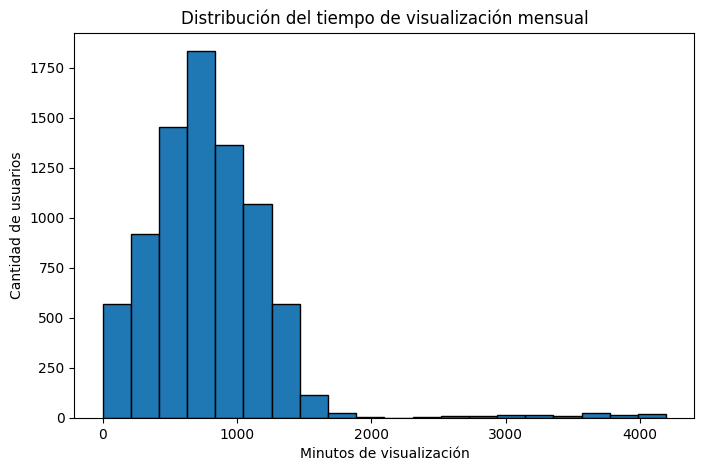

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df["minutos_visualizacion_mensual"],
         bins=20,
         edgecolor="black")

plt.title("Distribución del tiempo de visualización mensual")
plt.xlabel("Minutos de visualización")
plt.ylabel("Cantidad de usuarios")

plt.show()

#Justificación e interpretación
Se visualiza la cantidad de usuarios por la cantidad minutos que vizualizan para saber que cantidad de usuarios visualizan por mas minutos la plaraforma de streaming.

Se observa lo siguiente:
- La distribución tiene forma asimétrica hacia la derecha. La masa de usuarios se concentra entre 500 y 1200 minutos mensuales, con el pico más alto (1800 usuarios) alrededor de 700-800 minutos.
- Después de los 1500 minutos la frecuencia cae abruptamente, y se forma una cola larga y delgada que se extiende hasta 4000+ minutos, con muy pocos usuarios en esos valores.
- Esto indica que la mayoría de los clientes tiene un consumo moderado, mientras que un grupo pequeño y minoritario consume cantidades mucho mayores de contenido, son los "outliers" o usuarios de alto consumo que aparecen dispersos en la cola derecha.
En resumen: el gráfico muestra que el consumo "típico" ronda los 700-900 minutos al mes, pero existe un grupo chico de usuarios muy intensivos que se aleja bastante de ese comportamiento normal.

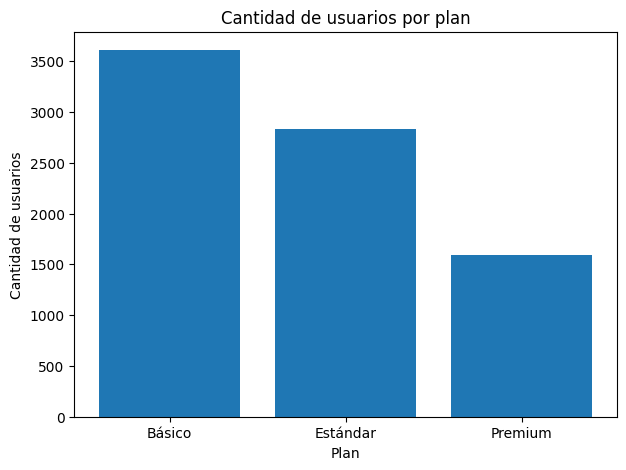

In [ ]:
planes = df["plan_suscripcion"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(planes.index,
        planes.values)

plt.title("Cantidad de usuarios por plan")
plt.xlabel("Plan")
plt.ylabel("Cantidad de usuarios")

plt.show()

#Justificación e Interpretación
Este es un gráfico de barras que busca mostrar la cantidad de usuarios según el tipo de plan al que están suscriptos: Básico, Estándar y Premium. para determinar cuales son las preferencias de los clientes a la hora de suscribirse a un plan.

Se observa lo siguiente:

- El plan Básico concentra la mayor cantidad de usuarios, con cerca de 3600.
- El plan Estándar le sigue con aproximadamente 2800 usuarios.
- El plan Premium es el que menos usuarios tiene, alrededor de 1500.
- Se observa una relación decreciente: a medida que el plan es más caro, la base de usuarios se reduce. Esto es totalmente logico, ya que, la mayoría opta por el plan más económico.

En resumen: la base de usuarios está concentrada mayormente en el plan más barato, y se va achicando a medida que subís de categoría hacia planes más premium.

#Analisis bivariado

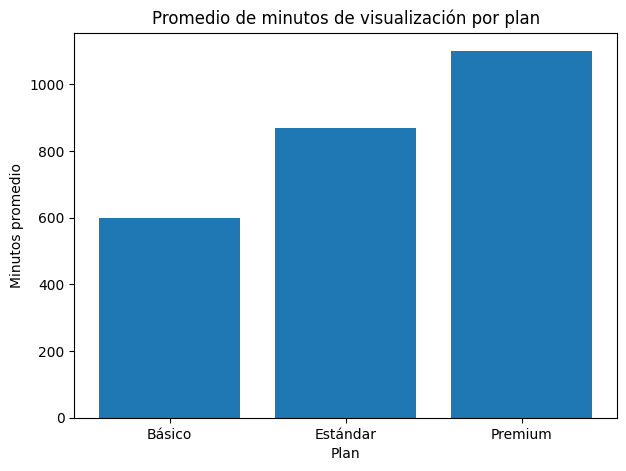

In [ ]:
promedio_plan = df.groupby("plan_suscripcion")["minutos_visualizacion_mensual"].mean()

plt.figure(figsize=(7,5))

plt.bar(promedio_plan.index,
        promedio_plan.values)

plt.title("Promedio de minutos de visualización por plan")
plt.xlabel("Plan")
plt.ylabel("Minutos promedio")

plt.show()

#Justificación e Intertpretación
Este es un gráfico de barras que muestra el promedio de minutos de visualización mensual según el tipo de plan: Básico, Estándar y Premium. En el eje X están los planes y en el eje Y los minutos promedio consumidos. En el se intenta encontrar alguna relación entre estas variables.

Se observa lo siguiente:

- El plan Básico tiene el promedio más bajo, alrededor de 600 minutos.
- El plan Estándar sube a cerca de 900 minutos.
- El plan Premium tiene el promedio más alto, cerca de 1050 minutos.
- Hay una relación creciente y clara: a mayor jerarquía del plan, mayor consumo promedio de contenido.

Este gráfico es clave para nuestra investigación porque, cruzado con el anterior (cantidad de usuarios por plan), muestra un patrón interesante: el plan Premium tiene la menor cantidad de usuarios pero el mayor consumo promedio individual. Es decir, los usuarios que más contenido consumen tienden a estar en los planes más altos, aunque sean minoría. Esto es un indicio fuerte de que el tipo de plan es una característica relevante del perfil de "alto consumo", y sugiere una oportunidad de negocio: ese segmento minoritario premium genera desproporcionadamente más tiempo de visualización.

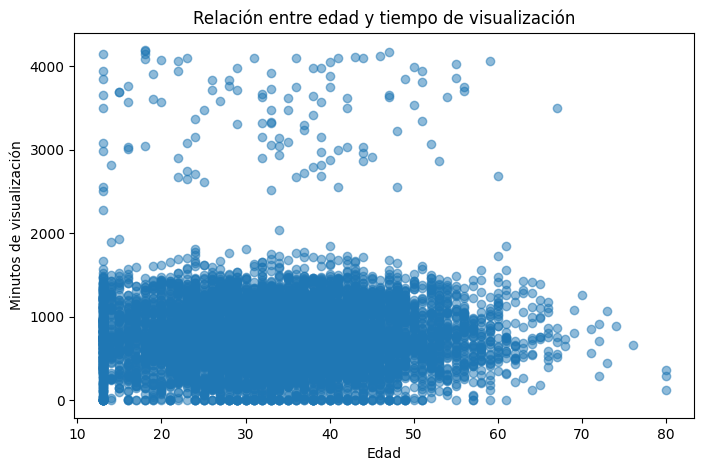

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["edad"],
            df["minutos_visualizacion_mensual"],
            alpha=0.5)

plt.title("Relación entre edad y tiempo de visualización")
plt.xlabel("Edad")
plt.ylabel("Minutos de visualización")

plt.show()

Este es un gráfico de dispersión (scatter plot) que cruza la edad de los usuarios (eje X) con sus minutos de visualización mensual (eje Y). que permite ver si existe relación entre ambas variables.

Lectura del gráfico

- Se ven dos grupos claramente separados (dos "nubes" de puntos)
 - Un grupo grande y denso entre 0 y 1700 minutos, presente en todas las edades (de 10 a 80 años).
 - Un segundo grupo, más disperso, ubicado entre 2500 y 4000 minutos, que se concentra sobre todo entre los 15 y 60 años, y prácticamente desaparece después de los 60.

 En resumen:- Dentro del grupo denso inferior, se nota una leve tendencia decreciente a partir de los 50-60 años: la nube se "angosta" hacia abajo, sugiriendo que los usuarios de mayor edad tienden a consumir menos minutos. En el grupo superior (alto consumo), la concentración es mayor entre los 15-45 años, lo que podría indicar que los usuarios jóvenes y adultos-jóvenes son los que más tiempo dedican a la plataforma. En general se observa que ambas grupos tienen un compratimiento similar, los usuarios que mas consumen se encuentran entre los 15 y 60 años, dato util a la hora de la estrategia publicitaria de la empresa y para especializar el contenido de la plataforma para los gustos de ese rango hetareo.


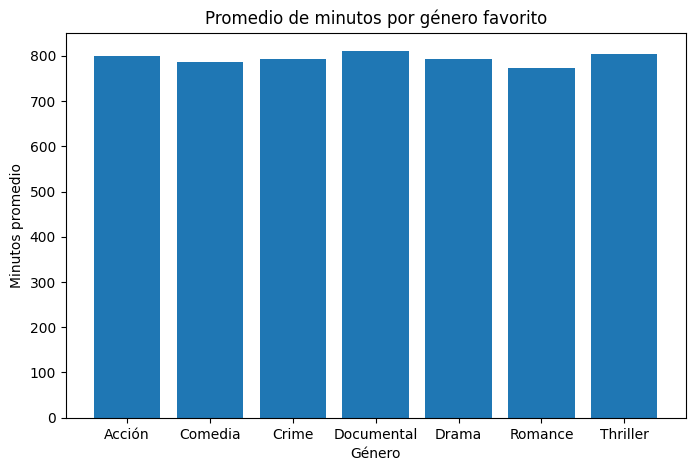

In [ ]:
promedio_genero = df.groupby("genero_favorito")["minutos_visualizacion_mensual"].mean()

plt.figure(figsize=(8,5))

plt.bar(promedio_genero.index,
        promedio_genero.values)

plt.title("Promedio de minutos por género favorito")
plt.xlabel("Género")
plt.ylabel("Minutos promedio")

plt.show()

#Justificación e interpretación

Se realiza este grafico para observar si hay relacion entre los minutos visualizados y el genero, para seber si este es deterrminante en los gustos de los usuarios

Se observa:

- No existe una tendencia notaria, se observa que la mayoria de los generos poseen casi la misma cantidad de minutos de visualización, lo que indica que es un dataset muy equilibrado y por ende el genero no tiene ninugna incidencia para el proposito de esta investigación.


#Analisis multivariado

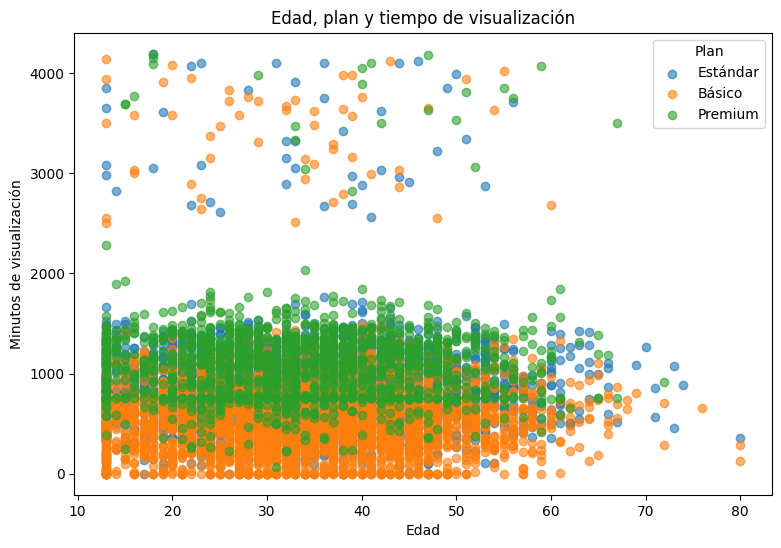

In [ ]:
plt.figure(figsize=(9,6))

planes = df["plan_suscripcion"].unique()

for plan in planes:

    datos = df[df["plan_suscripcion"] == plan]

    plt.scatter(
        datos["edad"],
        datos["minutos_visualizacion_mensual"],
        alpha=0.6,
        label=plan
    )

plt.title("Edad, plan y tiempo de visualización")

plt.xlabel("Edad")

plt.ylabel("Minutos de visualización")

plt.legend(title="Plan")

plt.show()

#Justificación e interpretación

Es el mismo scatter de edad vs. minutos de visualización de antes, pero ahora coloreado según el plan del usuario: azul (Estándar), naranja (Básico), verde (Premium). Este analisis multivariado permite ver si la variable plan explica esa separación en dos grupos que había detectado.

Se observa lo siguiente:

-La respuesta a la duda anterior queda resuelta, los tres planes están mezclados tanto en la nube densa inferior (0-1700 min) como en la nube superior (2500-4300 min). No es que "todo Premium" esté arriba y "todo Básico" abajo, hay usuarios Básico, Estándar y Premium en ambos grupos. Esto descarta que el salto fuera un error de carga asociado a un plan específico; es una separación de comportamiento que atraviesa a los tres planes.

-En la nube inferior (grueso de usuarios): se ve que el naranja (Básico) predomina en la parte más baja (cerca de 0), mientras que el verde (Premium) tiende a estar más presente en la franja superior de esa nube (cerca de 1500-1700). Esto es coherente con el gráfico de promedios de antes: Premium consume más en promedio.

-En la nube superior (alto consumo, 2500-4300 min): hay una mezcla de los tres colores sin un patrón dominante muy marcado, aunque a simple vista el naranja (Básico) y azul (Estándar) parecen tener bastante presencia también ahí, no es exclusivo de Premium. Esto es interesante porque contradice parcialmente la hipótesis anterior de que "el alto consumo es un fenómeno solo de Premium", hay usuarios Básico que consumen muchísimo, lo cual los convierte en excelentes candidatos para ofrecerles un plan mejor.

-Por edad: el patrón de caída después de los 60 años se mantiene para los tres planes por igual, no es un efecto exclusivo de un plan.

En resumen: este gráfico sugiere que el plan por sí solo no explica completamente quién es el usuario de alto consumo — hay usuarios de alto consumo en los tres planes. Esto refuerza la idea de que conviene identificar a esos "Básico intensivos" (naranja arriba) como el segmento más accionable para subirlos de plan, ya que ya consumen como un Premium pero pagan como Básico.

# Conclusiones generales del análisis EDA

Respondiendo a la pregunta de investigación: ¿Qué características tienen los usuarios que consumen más tiempo de contenido en la plataforma?

1. El consumo de contenido no es homogéneo — hay dos poblaciones diferenciadas

El histograma y el scatter mostraron que la mayoría de los usuarios (el grueso de la base) consume entre 500 y 1200 minutos/mes, pero existe un segmento minoritario y bien diferenciado que consume entre 2500 y 4300 minutos/mes. No es una cola gradual, sino un salto — sugiriendo que el usuario de "alto consumo" no es simplemente "un poco más" que el promedio, sino que responde a un patrón de uso cualitativamente distinto (posiblemente uso más intensivo, o cuentas con múltiples perfiles activos).

2. La edad es un factor relevante, pero de forma moderada

El consumo alto se concentra mayormente entre los 15 y 60 años, y decae notablemente después de los 60. La edad por sí sola no separa limpiamente a los grupos, pero sí actúa como un filtro: fuera de ese rango, el alto consumo prácticamente no aparece.

3. El plan de suscripción está asociado al consumo, pero no lo determina por completo

Premium tiene el mayor promedio de minutos (1050) y Básico el menor (600), lo que confirma una relación positiva entre plan y consumo. Sin embargo, el gráfico multivariado mostró que los tres planes tienen usuarios en el grupo de alto consumo — hay usuarios Básico y Estándar que consumen tanto como los Premium típicos. Esto es clave: el plan es un indicador parcial, no una etiqueta perfecta del perfil buscado.

4. Conclusión final

El usuario de alto consumo no se explica por una sola variable, sino por una combinación: tiende a tener entre 15-60 años, y aunque es más probable encontrarlo en plan Premium, existe un grupo significativo de usuarios Básico/Estándar "sobre-consumiendo" para su plan actual. Este último grupo es el hallazgo más importante del análisis.

En resumen: los usuarios que consumen más tiempo de contenido se caracterizan principalmente por estar en un rango etario de 15 a 60 años, y aunque muestran una mayor probabilidad de pertenecer al plan Premium, el consumo elevado también aparece de forma significativa en usuarios de planes Básico y Estándar. Esto indica que el alto consumo responde a un patrón de comportamiento (posiblemente por hábito de uso) más que exclusivamente a la categoría de suscripción contratada.

Recomendación para la etapa siguiente: con estas variables (edad, plan, minutos) podria realizarse un modelo predictivo para determinar el comportamiento de nuevos usuarios o clasificarlos en usuarios de alto o bajo consumo por ejemplo.